In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import geopandas as gpd

import cartopy.crs as ccrs
import scipy.stats as stats
import cartopy.feature as cfeature

import shapely.vectorized as sv

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

import shapely.geometry as sg
from shapely.geometry import Point

from sklearn.linear_model import LinearRegression

import sys
sys.path.append(os.path.abspath(".."))
from function import DOWN_raw
from function import ART_preprocessing as ART_pre

from playsound import playsound

import warnings
warnings.filterwarnings('ignore')

playsound is relying on another python subprocess. Please use `pip install pygobject` if you want playsound to run more efficiently.


In [2]:
dir_base = os.path.join('/', 'media', 'arturo', 'T9', 'Data', 'Italy')

## OBS data

In [3]:
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'ITALY', 0.002

veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

italy_geom = ITALY.union_all()

In [4]:
def get_parameters(product, dir_base, val_max=1.1, corrected=False, corr_method=None):
    # The list bellow is the rain gauges with suspect data
    list_remove = [
            'IT-820_1424_FTS_1440_QCv4.csv', 'IT-250_602781_FTS_1440_QCv4.csv', 
            'IT-250_602779_FTS_1440_QCv4.csv', 'IT-780_2370_FTS_1440_QCv4.csv', 
            'IT-750_450_FTS_1440_QCv4.csv', 'IT-520_TOS11000099_FTS_1440_QCv4.csv',
            'IT-520_TOS11000080_FTS_1440_QCv4.csv', 'IT-520_TOS11000072_FTS_1440_QCv4.csv',
            'IT-520_TOS11000060_FTS_1440_QCv4.csv', 'IT-520_TOS11000025_FTS_1440_QCv4.csv',
            'IT-520_TOS09001200_FTS_1440_QCv4.csv', 'IT-520_TOS02000237_FTS_1440_QCv4.csv',
            'IT-230_1200_FTS_1440_QCv4.csv'
            ]

    if corrected == True:
        if corr_method == 'QQc':
            print(f"Loading {product} corrected statistics...")
            hdf5_file = os.path.join(dir_base,'statistics','QQc',f'statistics_obs_{product}_corrected_{corr_method}.h5')
        else:
            raise ValueError("corr_method must be specified between 'QQc' or 'LRC' when corrected=True")
    else:
        hdf5_file = os.path.join(dir_base,'statistics',f'statistics_obs_{product}.h5')
    data = pd.HDFStore(hdf5_file, mode='r')

    keys = data.keys()
    keys_QUANTILES = [k for k in keys if k.endswith("/QUANTILES")]
    keys_INFO = [k for k in keys if k.endswith('/INFO')]

    stations = []
    lats, lons, elevs = [], [], []
    Nobs, Cobs, Wobs = [], [], []
    OBS, MEVd = [], []
    for nn in range(len(keys_INFO)):
        station = keys_INFO[nn].split('/')[2]
        
        if station in list_remove:
            continue
        else:
            lat = data[keys_INFO[nn]]['lat_obs'].values[0]
            lon = data[keys_INFO[nn]]['lon_obs'].values[0]
            elev = data[keys_INFO[nn]]['elev_obs'].values[0]
            Obs_ = data[keys_QUANTILES[nn]].OBS.values[3]
            Down_ = data[keys_QUANTILES[nn]].SAT_down.values[3] 

            stations.append(station)
            lats.append(lat)
            lons.append(lon)
            elevs.append(elev)
            OBS.append(Obs_)
            MEVd.append(Down_)

    DF_DATA = pd.DataFrame({'STATION':stations, 'LON':lons, 'LAT':lats, 'ELEV':elevs, 'OBS':OBS, 'MEVd':MEVd})

    return DF_DATA

def DF_elevation_QQc(DF):
    group_colors = {'≤25%':  '#2c7bb6','25–50%': '#abd9e9','50–75%': '#fdae61','>75%':   '#d7191c'}
    
    Elevation_norm = (DF.ELEV.values - np.min(DF.ELEV.values)) / (np.max(DF.ELEV.values) - np.min(DF.ELEV.values))

    DF['ELEVn'] = Elevation_norm

def linear_regression(DF,val):
    OBS = DF.OBS.values
    DOWN = DF[val].values
    mask = ~np.isnan(OBS) & ~np.isnan(DOWN)
    obs_clean = OBS[mask].reshape(-1, 1) 
    down_clean = DOWN[mask]

    reg = LinearRegression()
    reg.fit(obs_clean, down_clean)

    # Obtener el slope (pendiente)
    slope = reg.coef_[0]
    
    x_line = np.linspace(np.min(obs_clean), np.max(obs_clean), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)

    return x_line, y_line, slope

def calculate_mare(obs, mod, eps=1e-6):
    """
    Mean Absolute Relative Error (MARE)

    obs, mod : arrays (nt, ny, nx) o compatibles
    eps      : evita división por cero
    """
    re = (mod - obs) / (obs + eps)
    return np.nanmean(np.abs(re), axis=0)

In [5]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
bias_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','6_DOWN_BCorrected','TEST')

METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy.csv'))
METADATA["Lat"] = np.round(METADATA["Lat"], 6)
METADATA["Lon"] = np.round(METADATA["Lon"], 6)

ISO_names = np.unique(METADATA.ISO.values)




lats, lons = [], []
QUANTILE = []

for rr in range(len(ISO_names)):
    region_ISO = ISO_names[rr]

    INFO_dict = {}
    WEIBULL_dict = {}
    QUANTILES_dict = {}

    # print(f'{rr+1}: {region_ISO}')

    METADATA_clear = METADATA[METADATA['ISO']==region_ISO].reset_index(inplace=False)

    for nn in range(len(METADATA_clear)):#len(METADATA_clear)
        filename = f'{METADATA_clear['File'].values[nn]}'
        lat_obs = METADATA_clear['Lat'][nn]
        lon_obs = METADATA_clear['Lon'][nn]
        elev_obs = METADATA_clear['DEM_Elevation'][nn]

        OBS_pd = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', region_ISO, filename))
        OBS_pd = OBS_pd[(OBS_pd['Year']>=2002)&(OBS_pd['Year']<=2023)].reset_index(drop=True)
        
        if len(OBS_pd) == 0:
            continue

        else:
            OBS_N = OBS_pd['N'].values
            OBS_C = OBS_pd['C'].values
            OBS_W = OBS_pd['W'].values
            OBS_Y = OBS_pd['Year'].values

            mask = ~np.isnan(OBS_N)

            OBS_N = OBS_N[mask]
            OBS_C = OBS_C[mask]
            OBS_W = OBS_W[mask]
            OBS_Y = OBS_Y[mask]

            if len(OBS_Y) >= 8: # greather than 8 years

                x0 = np.nanmean(OBS_C)
                OBS_Q, flag = DOWN_raw.mev_quant_update(Fi, x0, OBS_N, OBS_C, OBS_W, thresh=1)
                OBS_Q2 = np.where(flag, OBS_Q, np.nan)

                lats.append(lat_obs)
                lons.append(lon_obs)
                QUANTILE.append(OBS_Q2[3])

Quantile_pd = pd.DataFrame({'lat':lats,'lon':lons,'Quantile':QUANTILE})
Quantile_clear = Quantile_pd[Quantile_pd['Quantile']<500]
Q_norm = (Quantile_clear['lat'].values - np.nanmin(Quantile_clear['lat'].values))/(np.nanmax(Quantile_clear['lat'].values)-np.nanmin(Quantile_clear['lat'].values)) *2

In [6]:
frac = 0.7
# seeds_list = [7, 19, 31, 53, 89, 127, 211, 307]
seeds_list = [7]

for seed in seeds_list:
    print(f'Seed: {seed}')

    dir_ = os.path.join('/','media','arturo','T9','Data','Italy')
    DF_INPUT = get_parameters('ENSEMBLE_ALL_MEDIAN',dir_)


    METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy.csv'))
    METADATA_CLEAR = METADATA[METADATA['File'].isin(DF_INPUT['STATION'])].reset_index(drop=True)

    Q_train_list = []
    Q_val_list = []

    for iso in METADATA_CLEAR['ISO'].unique():

        META_iso = METADATA_CLEAR[METADATA_CLEAR['ISO'] == iso]

        if len(META_iso) < 2:
            Q_train_list.append(META_iso)
            continue

        META_80 = META_iso.sample(frac=frac, random_state=seed)
        META_20 = META_iso.drop(META_80.index)

        Q_train_list.append(META_80)
        Q_val_list.append(META_20)

    Q_train = pd.concat(Q_train_list, ignore_index=True)
    Q_val = pd.concat(Q_val_list, ignore_index=True)
    list_train = Q_train.File.values

    DF_validation = DF_INPUT[DF_INPUT['STATION'].isin(Q_val['File'])].reset_index(drop=True)

DF_validation = DF_validation.drop(columns=['MEVd'])

lat_obs = DF_validation.LAT.values
lon_obs = DF_validation.LON.values

DF_elevation_QQc(DF_validation)

Seed: 7


## MEVd Ensemble

In [7]:
ENS_base = os.path.join('/','media','arturo','T9','Data','Italy')
seeds_list = [7, 19, 31, 53, 89, 127, 211, 307]

### Downscaling MEVD

In [8]:
dir_in = os.path.join(ENS_base,'Satellite','5_ENSEMBLE',f'ITALY_ENSEMBLE_ALL_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_median.nc')
DATA_MEVd = xr.open_dataset(dir_in)
lon2d, lat2d, = np.meshgrid(DATA_MEVd.lon, DATA_MEVd.lat)
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

IT_MEVd = DATA_MEVd.Mev_d[3,:,:].where(mask_italy)

### Downscaling PARAM corrected

In [9]:
MEVd_Median_PARAM = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,'Satellite','6_DOWN_BCorrected','PARAM','LTO',f'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_LTO_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)  
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    MEVd_Median_PARAM[nn,:,:] = DATA.Mev_d[3,:,:].where(mask_italy)

    nn = nn + 1

# aqui obtener la mediana
MEVd_Median_PARAM_clear = np.nanmedian(MEVd_Median_PARAM,axis=0)

NC_PARAM = xr.Dataset(
        data_vars={
            "Mev_d": (("lat","lon"), MEVd_Median_PARAM_clear),
            },
        coords={
            'lat': DATA_MEVd.lat, 
            'lon': DATA_MEVd.lon
            },)

IT_PARAM = NC_PARAM.Mev_d.where(mask_italy)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


### Downscaling QUANTILES corrected

In [10]:
MEVd_Median_QUANTILES = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,'Satellite','6_DOWN_BCorrected','QUANTILE',f'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_QQc_LLc_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)  
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    MEVd_Median_QUANTILES[nn,:,:] = DATA.MEVd_LTO.where(mask_italy)

    nn = nn + 1

# aqui obtener la mediana
MEVd_Median_QUANTILES_clear = np.nanmedian(MEVd_Median_QUANTILES,axis=0)

NC_QUANTILE = xr.Dataset(
        data_vars={
            "Mev_d": (("lat","lon"), MEVd_Median_QUANTILES_clear),
            },
        coords={
            'lat': DATA_MEVd.lat, 
            'lon': DATA_MEVd.lon
            },)

IT_QUANTILE = NC_QUANTILE.Mev_d.where(mask_italy)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


### Downscaling QUANTILES corrected median

In [11]:
MEVd_Median_QUANTILESd = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,'Satellite','6_DOWN_BCorrected','QUANTILE',f'ITALY_DOWN_ENSEMBLEd_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_QQc_LLc_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)  
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    MEVd_Median_QUANTILESd[nn,:,:] = DATA.MEVd_LTO.where(mask_italy)

    nn = nn + 1

# aqui obtener la mediana
MEVd_Median_QUANTILESd_clear = np.nanmedian(MEVd_Median_QUANTILESd,axis=0)

NC_QUANTILEd = xr.Dataset(
        data_vars={
            "Mev_d": (("lat","lon"), MEVd_Median_QUANTILESd_clear),
            },
        coords={
            'lat': DATA_MEVd.lat, 
            'lon': DATA_MEVd.lon
            },)

IT_QUANTILEd = NC_QUANTILEd.Mev_d.where(mask_italy)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


### Extract Nearest points

In [12]:
MEVd = []
MEVd_PARAM = []
MEVd_QUANTILE = []
MEVd_QUANTILEd = []

for nn in range(len(lat_obs)):
    MEVd_tmp = DATA_MEVd.sel(lat=lat_obs[nn], lon=lon_obs[nn], method='nearest').Mev_d[3].values
    MEVd.append(float(MEVd_tmp))
    
    MEVd_PARAM_tmp = NC_PARAM.sel(lat=lat_obs[nn], lon=lon_obs[nn], method='nearest').Mev_d.values
    MEVd_PARAM.append(float(MEVd_PARAM_tmp))
    
    MEVd_QUANTILE_tmp = NC_QUANTILE.sel(lat=lat_obs[nn], lon=lon_obs[nn], method='nearest').Mev_d.values
    MEVd_QUANTILE.append(float(MEVd_QUANTILE_tmp))
    
    MEVd_QUANTILEd_tmp = NC_QUANTILEd.sel(lat=lat_obs[nn], lon=lon_obs[nn], method='nearest').Mev_d.values
    MEVd_QUANTILEd.append(float(MEVd_QUANTILEd_tmp))

In [13]:
DF_validation['MEVd'] = MEVd
DF_validation['MEVd_PARAM'] = MEVd_PARAM
DF_validation['MEVd_QUANTILE'] = MEVd_QUANTILE
DF_validation['MEVd_QUANTILEd'] = MEVd_QUANTILEd

In [14]:
DF_validation['RE_MEVd'] = (MEVd-DF_validation.OBS)/DF_validation.OBS
DF_validation['RE_MEVd_PARAM'] = (MEVd_PARAM-DF_validation.OBS)/DF_validation.OBS
DF_validation['RE_MEVd_QUANTILE'] = (MEVd_QUANTILE-DF_validation.OBS)/DF_validation.OBS
DF_validation['RE_MEVd_QUANTILEd'] = (MEVd_QUANTILEd-DF_validation.OBS)/DF_validation.OBS

## Original QUANTILES DOWNSCALED

In [15]:
Mev_levels = np.arange(40, 320, 10)
Mev_cmap = plt.cm.Spectral_r
norm = BoundaryNorm(Mev_levels, ncolors=Mev_cmap.N, clip=True)

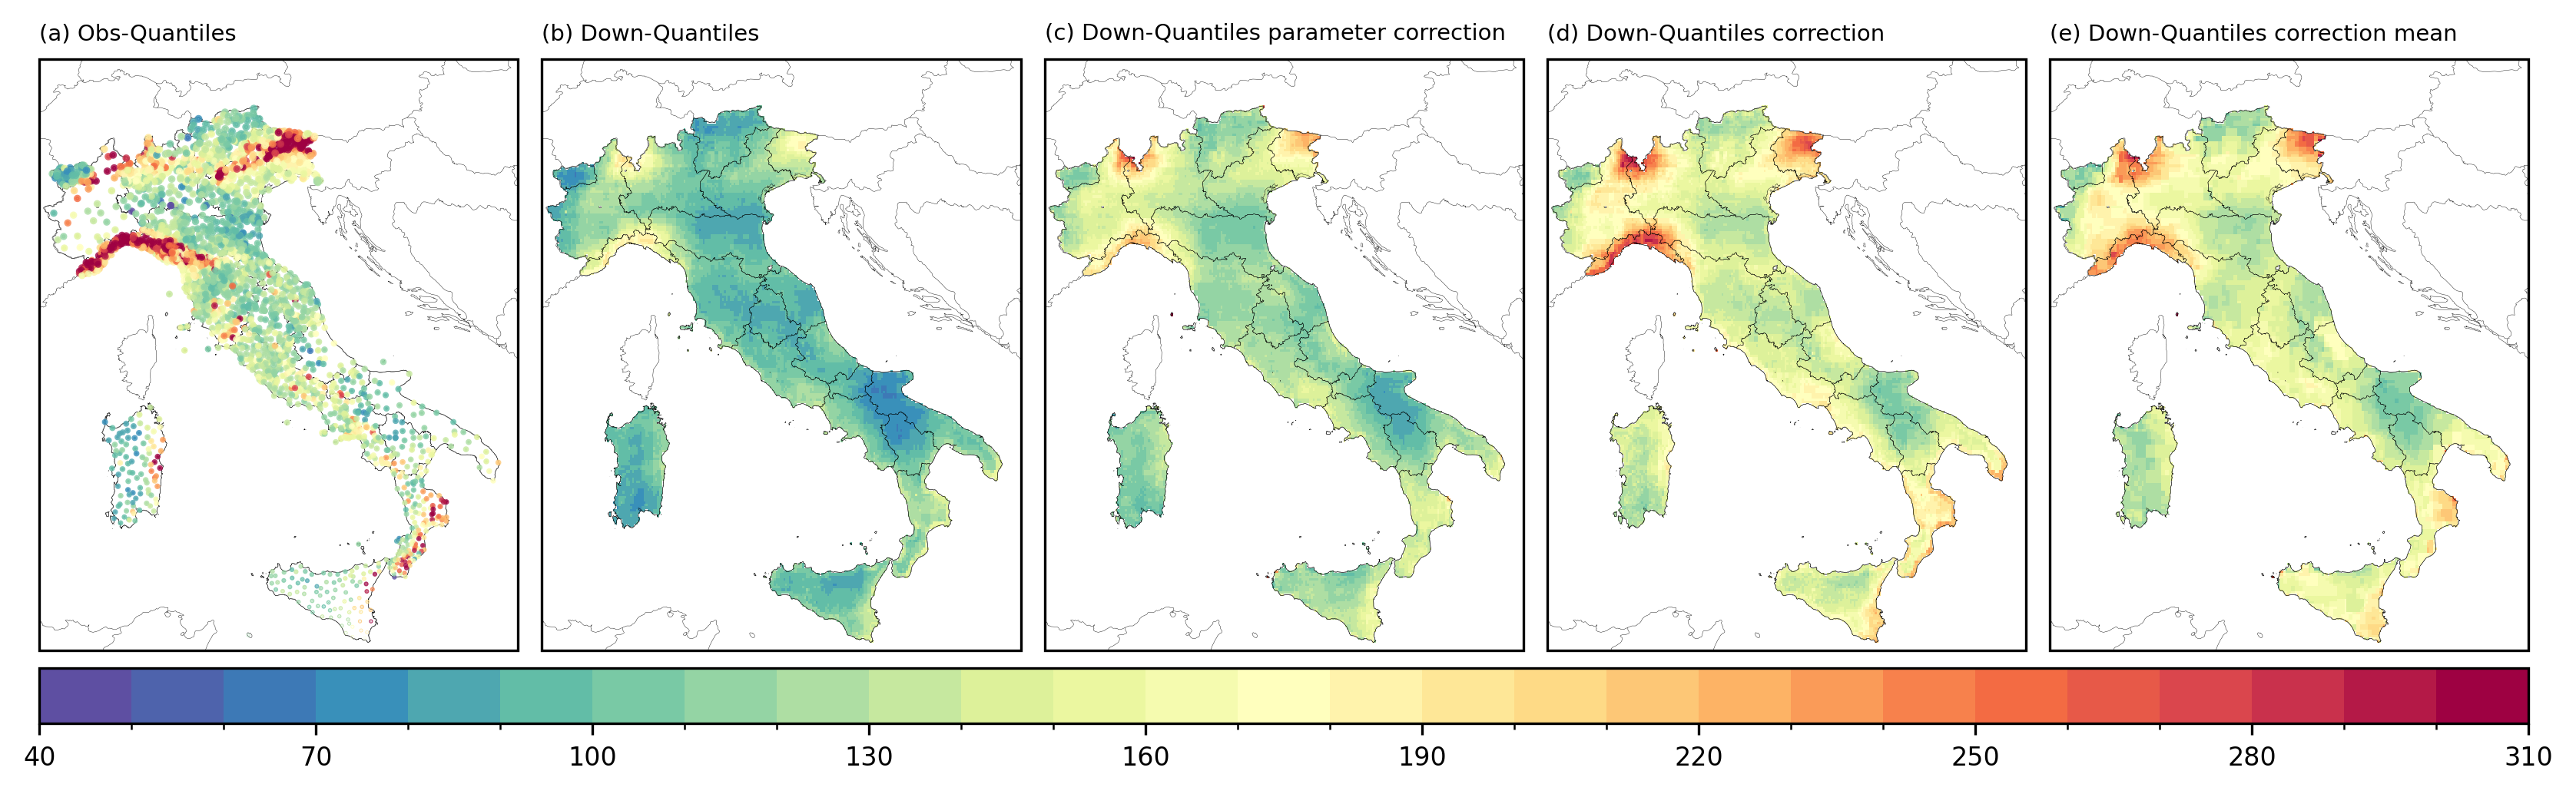

In [16]:
proj = ccrs.PlateCarree()

Mev_cmap = plt.cm.Spectral_r
diff_map = plt.cm.coolwarm_r
norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)

fig = plt.figure(figsize=(12,4),dpi=300)
gs = gridspec.GridSpec(1,5)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.scatter(Quantile_clear['lon'].values, Quantile_clear['lat'].values, c=Quantile_clear['Quantile'].values, s=Q_norm, alpha=0.8,cmap=Mev_cmap,norm=norm, zorder=10)
ax1.set_title('(a) Obs-Quantiles',loc='left',fontsize=7)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, IT_MEVd, cmap=Mev_cmap, norm=norm)
ax1.set_title('(b) Down-Quantiles',loc='left',fontsize=7)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, IT_PARAM, cmap=Mev_cmap, norm=norm)
ax1.set_title('(c) Down-Quantiles parameter correction',loc='left',fontsize=7)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 3], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, IT_QUANTILE, cmap=Mev_cmap, norm=norm)
ax1.set_title('(d) Down-Quantiles correction',loc='left',fontsize=7)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 4], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, IT_QUANTILEd, cmap=Mev_cmap, norm=norm)
ax1.set_title('(e) Down-Quantiles correction mean',loc='left',fontsize=7)

# ===========================================================================================================================================================================
cbar_ax = fig.add_axes([0.05, 0.1, 0.9, 0.06])
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=8)

# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.1)

In [17]:
labels = ["DOWN", "PARAM", "QUANTILE", "QUANTILEd"]

DOWN_mare = np.array([
                    np.round(calculate_mare(DF_validation.OBS, DF_validation.MEVd),3),
                    np.round(calculate_mare(DF_validation.OBS, DF_validation.MEVd_PARAM),3),
                    np.round(calculate_mare(DF_validation.OBS, DF_validation.MEVd_QUANTILE),3),
                    np.round(calculate_mare(DF_validation.OBS, DF_validation.MEVd_QUANTILEd),3),
                    ])

DOWN_corrs = np.array([
                    np.round(DF_validation.OBS.corr(DF_validation.MEVd),3),
                    np.round(DF_validation.OBS.corr(DF_validation.MEVd_PARAM),3),
                    np.round(DF_validation.OBS.corr(DF_validation.MEVd_QUANTILE),3),
                    np.round(DF_validation.OBS.corr(DF_validation.MEVd_QUANTILEd),3),
                    ])

DOWN_std = np.array([
                    np.round(np.std(DF_validation.RE_MEVd),3),
                    np.round(np.std(DF_validation.RE_MEVd_PARAM),3), 
                    np.round(np.std(DF_validation.RE_MEVd_QUANTILE),3),
                    np.round(np.std(DF_validation.RE_MEVd_QUANTILEd),3), 
                    ])

DOWN_mean = np.array([
        np.round(np.nanmean(DF_validation.RE_MEVd),3),
        np.round(np.nanmean(DF_validation.RE_MEVd_PARAM),3),
        np.round(np.nanmean(DF_validation.RE_MEVd_QUANTILE),3),
        np.round(np.nanmean(DF_validation.RE_MEVd_QUANTILEd),3),
    ])

DOWN_median = np.array([
        np.round(np.nanmedian(DF_validation.RE_MEVd),3),
        np.round(np.nanmedian(DF_validation.RE_MEVd_PARAM),3),
        np.round(np.nanmedian(DF_validation.RE_MEVd_QUANTILE),3),
        np.round(np.nanmedian(DF_validation.RE_MEVd_QUANTILEd),3),
    ])

DOWN_diff = abs(DOWN_mean - DOWN_median)

DOWN_IQ = np.array([
        np.round(np.nanpercentile(DF_validation.RE_MEVd, 75) - np.nanpercentile(DF_validation.RE_MEVd, 25),3),
        np.round(np.nanpercentile(DF_validation.RE_MEVd_PARAM, 75) - np.nanpercentile(DF_validation.RE_MEVd_PARAM, 25),3),
        np.round(np.nanpercentile(DF_validation.RE_MEVd_QUANTILE, 75) - np.nanpercentile(DF_validation.RE_MEVd_QUANTILE, 25),3),
        np.round(np.nanpercentile(DF_validation.RE_MEVd_QUANTILEd, 75) - np.nanpercentile(DF_validation.RE_MEVd_QUANTILEd, 25),3),
    ])

RSR_DOWN_compare = pd.DataFrame({
        "Dataset": labels,
        "STD": DOWN_std,
        "Mean": DOWN_mean,
        "Median": DOWN_median,
        "DIFF":DOWN_diff,
        "IQR": DOWN_IQ,
        "CORR": DOWN_corrs,
        "MARE": DOWN_mare,
    })

## Scatter plot

In [19]:
DF_validation

,STATION,LON,LAT,ELEV,OBS,ELEVn,MEVd,MEVd_PARAM,MEVd_QUANTILE,MEVd_QUANTILEd,RE_MEVd,RE_MEVd_PARAM,RE_MEVd_QUANTILE,RE_MEVd_QUANTILEd
0,IT-880_35807_FTS_1440_QCv4.csv,8.965278,39.157227,159.336197,181.723288,0.052851,83.499676,92.598988,123.396550,116.452029,-0.540512,-0.490440,-0.320965,-0.359179
1,IT-880_35540_FTS_1440_QCv4.csv,9.411671,40.109446,1209.157959,219.866846,0.397336,119.634501,133.801726,176.796909,157.092630,-0.455877,-0.391442,-0.195891,-0.285510
2,IT-880_35515_FTS_1440_QCv4.csv,9.513059,39.795554,573.283875,211.849633,0.188682,106.012919,128.514434,156.666816,148.725585,-0.499584,-0.393370,-0.260481,-0.297966
3,IT-880_33554_FTS_1440_QCv4.csv,9.345005,39.620278,308.236511,135.557756,0.101710,88.889288,109.356566,131.361364,126.429459,-0.344270,-0.193284,-0.030956,-0.067339
4,IT-880_33540_FTS_1440_QCv4.csv,9.486662,39.206948,716.661804,135.191572,0.235730,92.849627,104.136644,137.213988,128.432719,-0.313200,-0.229711,0.014960,-0.049995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,IT-210_PIE-004001-900_FTS_1440_QCv4.csv,6.981407,44.485146,1595.432007,131.759318,0.524086,90.267248,129.914865,133.397727,149.080782,-0.314908,-0.013999,0.012435,0.131463
804,IT-210_PIE-003032-900_FTS_1440_QCv4.csv,8.693775,45.548011,171.041504,161.597677,0.056691,121.424147,162.171129,179.441663,203.965142,-0.248602,0.003549,0.110422,0.262179
805,IT-210_PIE-001259-900_FTS_1440_QCv4.csv,6.876103,45.002280,2281.249023,97.292771,0.749128,84.884750,114.825198,125.443424,123.587645,-0.127533,0.180203,0.289340,0.270265
806,IT-210_PIE-001139-900_FTS_1440_QCv4.csv,7.241139,44.812810,474.270203,243.082321,0.156192,99.754815,126.695476,147.418535,157.189406,-0.589625,-0.478796,-0.393545,-0.353349


In [18]:
RSR_DOWN_compare

,Dataset,STD,Mean,Median,DIFF,IQR,CORR,MARE
0,DOWN,0.205,-0.246,-0.239,0.007,0.231,0.649,0.271
1,PARAM,0.258,-0.079,-0.077,0.002,0.307,0.643,0.201
2,QUANTILE,0.297,0.107,0.119,0.012,0.349,0.661,0.241
3,QUANTILEd,0.301,0.089,0.096,0.007,0.352,0.648,0.235


In [28]:
MEVd_x, MEVd_y, MEVd_slope = linear_regression(DF_validation,'MEVd')
PARAM_x, PARAM_y, PARAM_slope = linear_regression(DF_validation,'MEVd_PARAM')
QUANTILE_x, QUANTILE_y, QUANTILE_slope = linear_regression(DF_validation,'MEVd_QUANTILE')
QUANTILEd_x, QUANTILEd_y, QUANTILEd_slope = linear_regression(DF_validation,'MEVd_QUANTILEd')

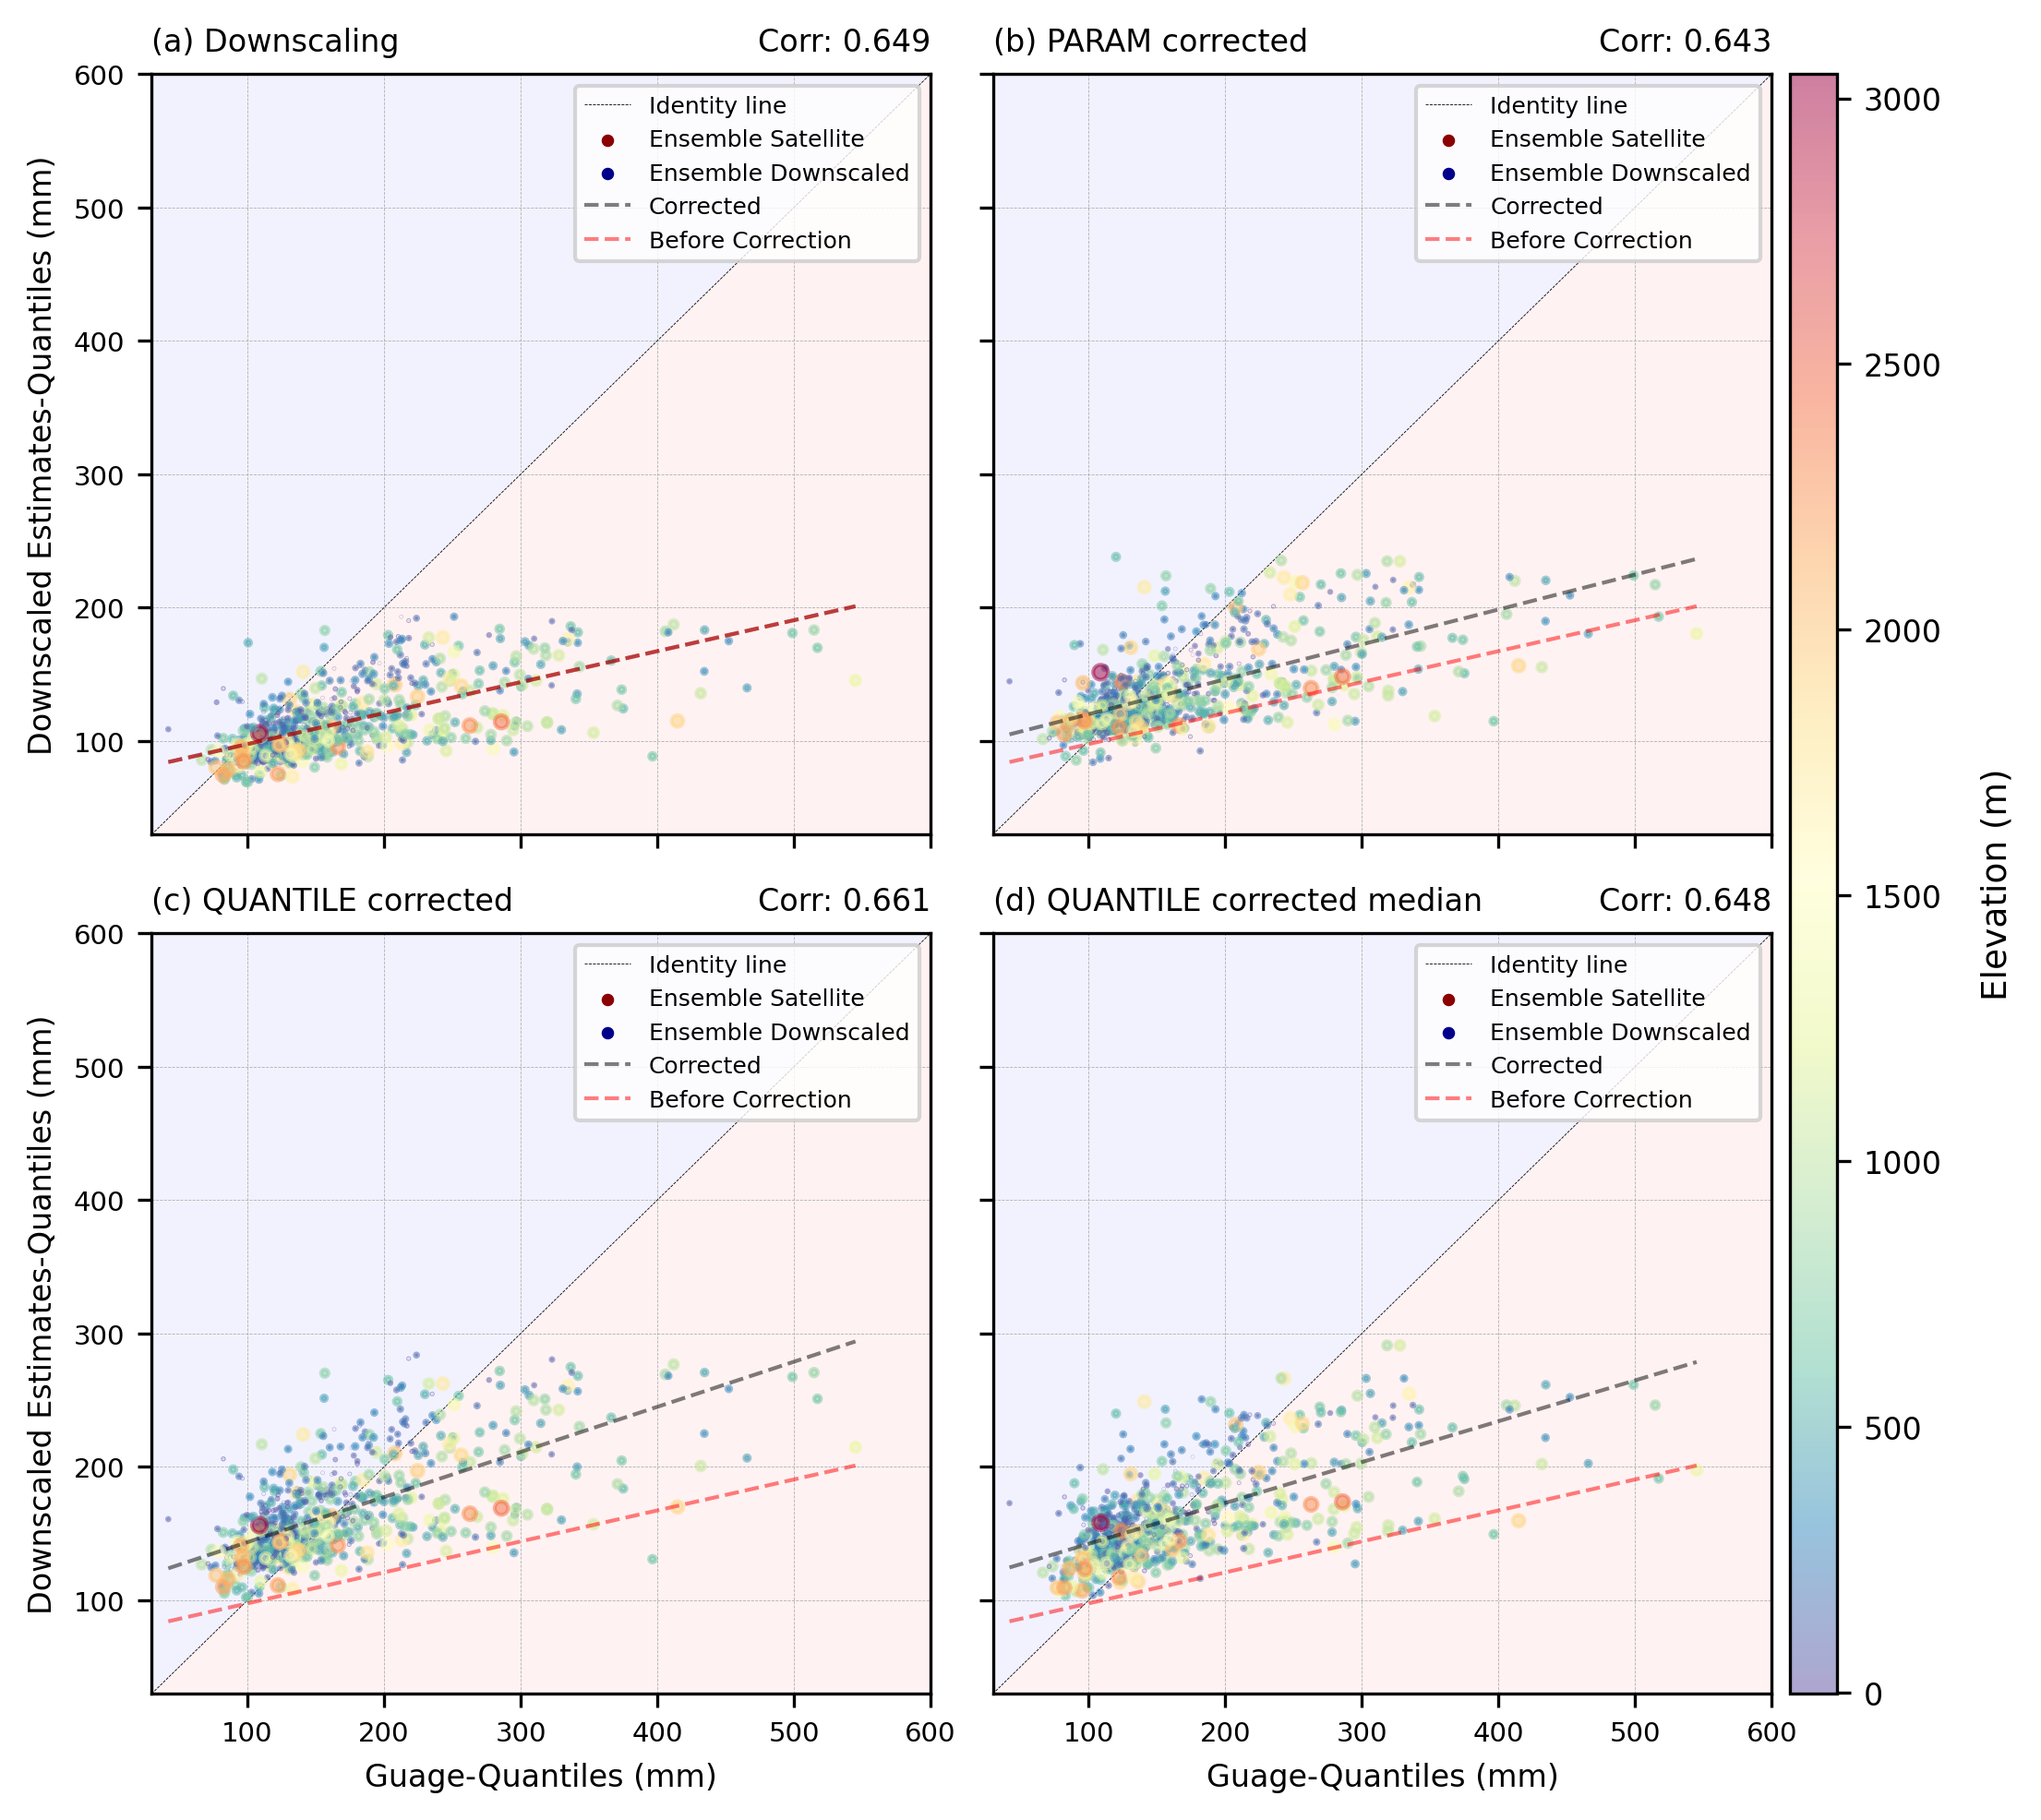

In [39]:
title_fontsize = 8

val_max = 600
vmin = DF_validation.ELEV.min()
vmax = DF_validation.ELEV.max()

fig = plt.figure(figsize=(6.5,6.5),dpi=300)
gs = gridspec.GridSpec(2, 2)

# ==========================================================================================================
axes = {}
pos = 0
for nrow in range(2):
    for ncol in range(2):
        ax = fig.add_subplot(gs[nrow, ncol])
        ax.grid(linewidth=0.3, linestyle='--')
        ax.set_xlim(30,val_max)
        ax.set_ylim(30,val_max)
        ax.grid(linestyle='--', linewidth=0.2)
        ax.tick_params(axis='both', which='major', labelsize=7)
        
        ax.plot(np.arange(val_max+50),np.arange(val_max+50),'--k', linewidth=0.2, label='Identity line')
        ax.scatter([],[], s=5, c='darkred', label='Ensemble Satellite')
        ax.scatter([],[], s=5, c='darkblue', label='Ensemble Downscaled')

        if ncol > 0:
            ax.set_yticklabels([])
        if nrow == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel('Guage-Quantiles (mm)',fontsize=8)
        if ncol == 0:
            ax.set_ylabel('Downscaled Estimates-Quantiles (mm)',fontsize=8)

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        x_vals = np.linspace(min(xlim[0], ylim[0]), max(xlim[1], ylim[1]), 200)
        ax.fill_between(x_vals, ylim[0], x_vals, facecolor="red", alpha=0.05, zorder=0)
        ax.fill_between(x_vals, x_vals, ylim[1], facecolor="blue", alpha=0.05, zorder=0)

        axes[(nrow, ncol)] = ax

# ==========================================================================================================
a1 = axes[(0, 0)].scatter(
    DF_validation.OBS, DF_validation.MEVd,
    alpha=0.5,
    s=DF_validation.ELEVn*15,
    c=DF_validation.ELEV,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")
axes[(0, 0)].plot(MEVd_x, MEVd_y, "--k", linewidth=1, label="Corrected", alpha=0.5,zorder=12)
axes[(0, 0)].set_title('(a) Downscaling', loc='left', fontsize=title_fontsize)
axes[(0, 0)].set_title(f'Corr: {RSR_DOWN_compare.CORR[0]}', loc='right', fontsize=title_fontsize)

# ==========================================================================================================
a2 = axes[(0, 1)].scatter(
    DF_validation.OBS, DF_validation.MEVd_PARAM,
    alpha=0.5,
    s=DF_validation.ELEVn*15,
    c=DF_validation.ELEV,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")
axes[(0, 1)].plot(PARAM_x, PARAM_y, "--k", linewidth=1, label="Corrected", alpha=0.5,zorder=12)
axes[(0, 1)].set_title('(b) PARAM corrected', loc='left', fontsize=title_fontsize)
axes[(0, 1)].set_title(f'Corr: {RSR_DOWN_compare.CORR[1]}', loc='right', fontsize=title_fontsize)

# ==========================================================================================================
a2 = axes[(1, 0)].scatter(
    DF_validation.OBS, DF_validation.MEVd_QUANTILE,
    alpha=0.5,
    s=DF_validation.ELEVn*15,
    c=DF_validation.ELEV,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")
axes[(1, 0)].plot(QUANTILE_x, QUANTILE_y, "--k", linewidth=1, label="Corrected", alpha=0.5,zorder=12)
axes[(1, 0)].set_title('(c) QUANTILE corrected', loc='left', fontsize=title_fontsize)
axes[(1, 0)].set_title(f'Corr: {RSR_DOWN_compare.CORR[2]}', loc='right', fontsize=title_fontsize)

# ==========================================================================================================
a2 = axes[(1, 1)].scatter(
    DF_validation.OBS, DF_validation.MEVd_QUANTILEd,
    alpha=0.5,
    s=DF_validation.ELEVn*15,
    c=DF_validation.ELEV,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")
axes[(1, 1)].plot(QUANTILEd_x, QUANTILEd_y, "--k", linewidth=1, label="Corrected", alpha=0.5,zorder=12)
axes[(1, 1)].set_title('(d) QUANTILE corrected median', loc='left', fontsize=title_fontsize)
axes[(1, 1)].set_title(f'Corr: {RSR_DOWN_compare.CORR[3]}', loc='right', fontsize=title_fontsize)

# ==========================================================================================================
axes[(0, 0)].plot(MEVd_x, MEVd_y, "--r", linewidth=1, label="Before Correction", alpha=0.5,zorder=12)
axes[(0, 1)].plot(MEVd_x, MEVd_y, "--r", linewidth=1, label="Before Correction", alpha=0.5,zorder=12)
axes[(1, 0)].plot(MEVd_x, MEVd_y, "--r", linewidth=1, label="Before Correction", alpha=0.5,zorder=12)
axes[(1, 1)].plot(MEVd_x, MEVd_y, "--r", linewidth=1, label="Before Correction", alpha=0.5,zorder=12)

axes[(0, 0)].legend(fontsize=6,loc=1)
axes[(0, 1)].legend(fontsize=6,loc=1)
axes[(1, 0)].legend(fontsize=6,loc=1)
axes[(1, 1)].legend(fontsize=6,loc=1)

# ==========================================================================================================
# ==========================================================================================================
cbar_ax = fig.add_axes([0.96, 0.05, 0.026, 0.9]) #0.96
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Elevation (m)", fontsize=9, labelpad=10) 

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.13)


## Taylor plot

In [126]:
colors_T = ['k','r','g','b']
markers_T = ['o', 'o', 'o', 'o', '^', '^', '^', '^']

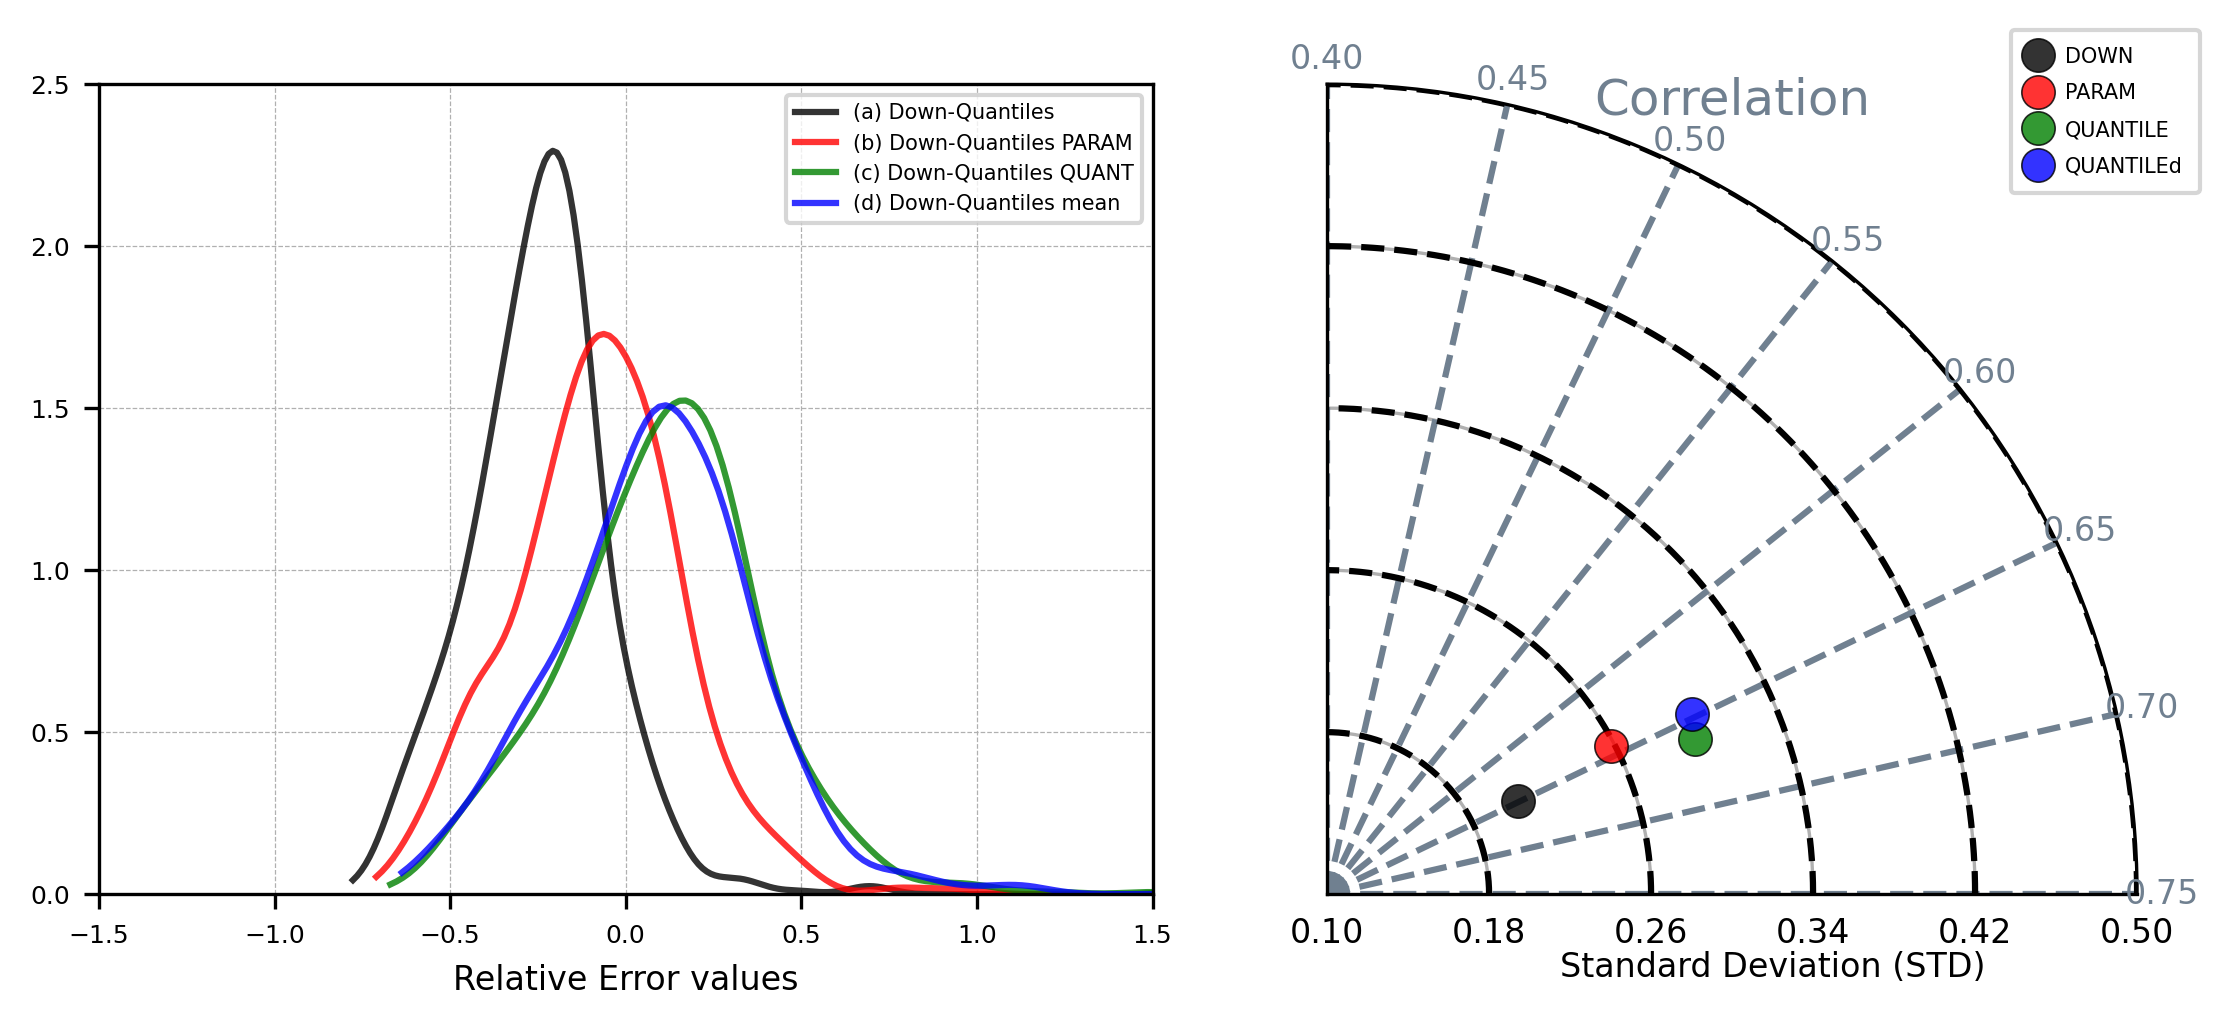

In [129]:

fig = plt.figure(figsize=(8,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])
sns.kdeplot(DF_validation.RE_MEVd,color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'(a) Down-Quantiles',
            clip=(np.nanmin(np.array(DF_validation.RE_MEVd)), np.nanmax(np.array(DF_validation.RE_MEVd))), alpha=0.8)

sns.kdeplot(DF_validation.RE_MEVd_PARAM,color='r',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'(b) Down-Quantiles PARAM',
            clip=(np.nanmin(np.array(DF_validation.RE_MEVd_PARAM)), np.nanmax(np.array(DF_validation.RE_MEVd_PARAM))), alpha=0.8)

sns.kdeplot(DF_validation.RE_MEVd_QUANTILE,color='g',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'(c) Down-Quantiles QUANT',
            clip=(np.nanmin(np.array(DF_validation.RE_MEVd_QUANTILE)), np.nanmax(np.array(DF_validation.RE_MEVd_QUANTILE))), alpha=0.8)

sns.kdeplot(DF_validation.RE_MEVd_QUANTILEd,color='b',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'(d) Down-Quantiles mean',
            clip=(np.nanmin(np.array(DF_validation.RE_MEVd_QUANTILEd)), np.nanmax(np.array(DF_validation.RE_MEVd_QUANTILEd))), alpha=0.8)

ax1.set_ylabel('',fontsize=8)
ax1.set_xlabel('Relative Error values',fontsize=8)
ax1.legend(fontsize=5, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,2.5)
ax1.tick_params(axis='both', which='major', labelsize=6)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], polar=True)
rmin = 0.1
rmax = 0.5

c_min = 0.4
c_max = 0.75
correlations = np.arange(c_min, c_max + 0.05, 0.05)

for c in correlations:
    theta = (c_max - c) / (c_max - c_min) * (np.pi/2)
    ax1.plot([theta, theta], [rmin, rmax], color="slategrey", linestyle="--")
    ax1.text(theta, rmax * 1.025, f"{c:.2f}", ha="center", va="center",
            fontsize=8, color="slategrey")

# --- NUEVOS CÍRCULOS RADIALES DE MARE ---
radial_ticks = np.linspace(rmin, rmax, 6)
for r in radial_ticks:
    ax1.plot(np.linspace(0, np.pi/2, 200), np.ones(200)*r, color="k", linestyle="--")

# --- LIMPIEZA DE EJE ANGULAR ---
ax1.xaxis.set_visible(False)

# --- PUNTOS DE MODELOS ---
for rmse_val, corr_val, lab, co, ma in zip(RSR_DOWN_compare.STD.values, RSR_DOWN_compare.CORR.values, RSR_DOWN_compare.Dataset.values, colors_T, markers_T):
    theta = (c_max - corr_val) / (c_max - c_min) * (np.pi/2)
    ax1.plot(theta, rmse_val, ma, markersize=8, 
            markeredgecolor='black',
            markeredgewidth=0.4,
            alpha=0.8, label=f'{lab}', color=co)

# --- LÍMITES Y DIRECCIÓN ---
ax1.set_thetamin(0)
ax1.set_thetamax(90)
ax1.set_theta_zero_location("E")
ax1.set_theta_direction(1)
ax1.set_rmin(rmin)
ax1.set_rmax(rmax)

# --- RADIAL TICKS ---
ax1.set_yticks(radial_ticks)
ax1.tick_params(axis='both', which='major', labelsize=8, pad=2)
ax1.grid(True)

plt.legend(fontsize=5, 
            ncol=1, 
            loc='upper right', 
            bbox_to_anchor=(1.09, 1.08),
            handlelength=1.0,      # Longitud de la línea del símbolo
            handletextpad=0.8,     # Espacio entre símbolo y texto
            borderpad=0.8,         # Padding interno
            labelspacing=0.8)      # Espacio entre etiquetas

# --- LABELS ---
ax1.text(0.55, -0.09, "Standard Deviation (STD)", transform=ax1.transAxes,ha="center", va="center", fontsize=8)

ax1.text(0.5, 0.98, "Correlation", transform=ax1.transAxes,
        ha="center", va="center", rotation=0, fontsize=12, color='slategrey')

# ax1.set_title('(d2) Taylor of LRc', loc='left', fontsize=12, pad=15)

# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.1)